# River Permafrost Figure 6 Demo

This notebook keeps the Figure 6-specific workflow local to the notebook. The reusable library surface is the `RiverPermafrost1D` model; the forcing ingestion, paired-run assembly, and figure layout below are intentionally notebook-scoped.

## Input files used here

The notebook reads [river_temperature_output.csv](data/river_temperature_output.csv) for:

- `DOY` in the source file, used once to construct a real `time` axis with a configurable reference year
- `Tw` as river water temperature in degrees C
- `DeltaH` as the stage-like series, renamed to `S` for inundation switching

It reads [deadhorse2_new_instrumentation_tg_merged.csv](data/Deadhorse_climate/new_instrumentation/deadhorse2_new_instrumentation_tg_merged.csv) for `Tg`, using the merged Deadhorse surface-temperature record up to 2018 and averaging by calendar day.


In [14]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import paleobeasts as pb
from paleobeasts.signal_models import RiverPermafrost1D


In [ ]:
river_data_path = 'data/river_temperature_output.csv'
tg_data_path = 'data/Deadhorse_climate/new_instrumentation/deadhorse2_new_instrumentation_tg_merged.csv'
spinup_cache_path = 'data/river_permafrost_spinup_state.npz'
river_reference_year = 2017
tw_scale = 1.0
stage_scale = 1.0
stage_offset = 0.0
stage_threshold = 0.0
tg_end_date = '2018-06-01'

river_df = pd.read_csv(river_data_path)
river_df = river_df.rename(columns={'DeltaH': 'S'})
river_df['DOY'] = pd.to_numeric(river_df['DOY'], errors='coerce')
river_df['Tw'] = pd.to_numeric(river_df['Tw'], errors='coerce') * tw_scale
river_df['S'] = pd.to_numeric(river_df['S'], errors='coerce') * stage_scale + stage_offset
river_df = river_df[['DOY', 'Tw', 'S']].dropna(subset=['Tw', 'S']).copy()
river_df['time'] = pd.Timestamp(f'{river_reference_year}-01-01') + pd.to_timedelta(river_df['DOY'] - 1, unit='D')
river_df = river_df.drop(columns='DOY')
river_df['month_day'] = river_df['time'].dt.strftime('%m-%d')

tg_df = pd.read_csv(tg_data_path, parse_dates=['date'])
tg_df = tg_df[tg_df['date'] <= pd.Timestamp(tg_end_date)].copy()
tg_df['Tg'] = pd.to_numeric(tg_df['Tg'], errors='coerce')
tg_df['month_day'] = tg_df['date'].dt.strftime('%m-%d')
tg_by_day = tg_df.groupby('month_day', sort=True)['Tg'].mean()

forcing_df = river_df.merge(tg_by_day.rename('Tg'), left_on='month_day', right_index=True, how='left')
forcing_df = forcing_df[['time', 'Tg', 'Tw', 'S']].dropna(subset=['Tg']).sort_values('time').reset_index(drop=True)
forcing_df[['time', 'Tg', 'Tw', 'S']].agg({'time': ['min', 'max'], 'Tg': ['min', 'max'], 'Tw': ['min', 'max'], 'S': ['min', 'max']})


<Axes: title={'center': 'Deadhorse surface temperature (Tg) by day of year'}, xlabel='date'>

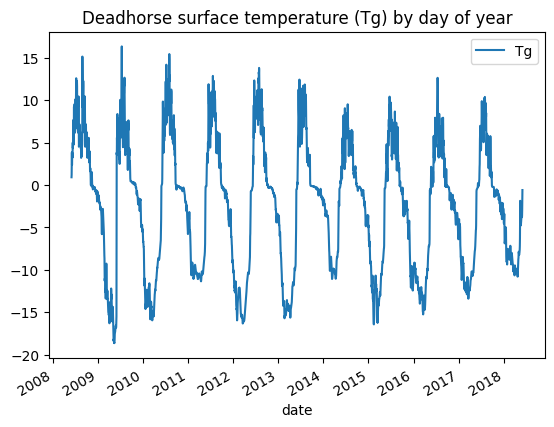

In [19]:
tg_df.plot(x='date', y='Tg', title='Deadhorse surface temperature (Tg) by day of year')

In [23]:
tg_by_day.index.max()

np.int64(366)

In [16]:
def repeat_annual_ground_cycle(forcing_df, spinup_years=100):
    month_day = forcing_df['time'].dt.strftime('%m-%d')
    cycle = forcing_df.groupby(month_day, sort=True)['Tg'].mean()
    repeated_values = np.tile(cycle.to_numpy(dtype=float), int(spinup_years))
    repeated_time = np.arange(repeated_values.size, dtype=float)
    return repeated_time, repeated_values

def forcing_from_series(time_days, values):
    return pb.Forcing(data=np.asarray(values, dtype=float), time=np.asarray(time_days, dtype=float), interpolation='linear')

def spinup_cache_key(forcing_df, spinup_years, dt, initial_temperature, model_kwargs):
    month_day = forcing_df['time'].dt.strftime('%m-%d')
    cycle = forcing_df.groupby(month_day, sort=True)['Tg'].mean().to_numpy(dtype=float)
    payload = {
        "spinup_years": int(spinup_years),
        "dt": float(dt),
        "initial_temperature": float(initial_temperature),
        "model_kwargs": {k: np.asarray(v).tolist() if isinstance(v, np.ndarray) else v for k, v in sorted(model_kwargs.items())},
        "tg_cycle": cycle.tolist(),
    }
    return json.dumps(payload, sort_keys=True)

def load_or_run_spinup(forcing_df, model_kwargs, spinup_years=100, dt=1.0, initial_temperature=-8.0, cache_path=None, force=False):
    spinup_time, spinup_tg = repeat_annual_ground_cycle(forcing_df, spinup_years=spinup_years)
    cache_key = spinup_cache_key(forcing_df, spinup_years, dt, initial_temperature, model_kwargs)

    if cache_path is not None and not force:
        cache_file = Path(cache_path)
        if cache_file.exists():
            cached = np.load(cache_file, allow_pickle=True)
            if str(cached['cache_key'].item()) == cache_key:
                return np.asarray(cached['state'], dtype=float)

    spinup_forcing = forcing_from_series(spinup_time, spinup_tg)
    spinup_stage = pb.Forcing(np.zeros_like(spinup_time, dtype=float), time=spinup_time, interpolation='linear')
    spinup_model = RiverPermafrost1D(Tg=spinup_forcing, Tw=spinup_forcing, S=spinup_stage, run_mode='dry', **model_kwargs)
    y0_spinup = np.full(spinup_model.n_layers, float(initial_temperature), dtype=float).tolist()
    spinup_model.integrate(t_span=(float(spinup_time[0]), float(spinup_time[-1])), y0=y0_spinup, method='euler', kwargs={'dt': float(dt)})
    state = np.asarray([spinup_model.state_variables[name][-1] for name in spinup_model.state_variables.dtype.names], dtype=float)

    if cache_path is not None:
        cache_file = Path(cache_path)
        np.savez(cache_file, cache_key=np.array(cache_key, dtype=object), state=state)

    return state

def run_fig6_case(forcing_df, model_kwargs=None, spinup_years=100, dt=1.0, initial_temperature=-8.0, spinup_cache_path=None, force_spinup=False):
    if model_kwargs is None:
        model_kwargs = {}

    forcing_df = forcing_df.copy()
    forcing_df['time'] = pd.to_datetime(forcing_df['time'])
    forcing_df = forcing_df.sort_values('time').reset_index(drop=True)

    time_index = pd.DatetimeIndex(forcing_df['time'])
    time_days = ((time_index - time_index[0]).total_seconds() / 86400.0).to_numpy(dtype=float)
    Tg = forcing_from_series(time_days, forcing_df['Tg'].to_numpy(dtype=float))
    Tw = forcing_from_series(time_days, forcing_df['Tw'].to_numpy(dtype=float))
    S = forcing_from_series(time_days, forcing_df['S'].to_numpy(dtype=float))

    spun_up_initial = load_or_run_spinup(
        forcing_df,
        model_kwargs=model_kwargs,
        spinup_years=spinup_years,
        dt=dt,
        initial_temperature=initial_temperature,
        cache_path=spinup_cache_path,
        force=force_spinup,
    )

    dry_model = RiverPermafrost1D(Tg=Tg, Tw=Tw, S=S, run_mode='dry', **model_kwargs)
    inundated_model = RiverPermafrost1D(Tg=Tg, Tw=Tw, S=S, run_mode='inundated', **model_kwargs)
    common_kwargs = dict(t_span=(float(time_days[0]), float(time_days[-1])), y0=spun_up_initial.tolist(), method='euler', kwargs={'dt': float(dt)})
    dry_model.integrate(**common_kwargs)
    inundated_model.integrate(**common_kwargs)

    z = dry_model.depth.copy()
    ts_dry = np.column_stack([dry_model.state_variables[name] for name in dry_model.state_variables.dtype.names])
    ts_inundated = np.column_stack([inundated_model.state_variables[name] for name in inundated_model.state_variables.dtype.names])
    model_time = time_index[0] + pd.to_timedelta(dry_model.time, unit='D')

    ds = xr.Dataset(
        data_vars={
            'Ts_dry': (('time', 'z'), ts_dry),
            'Ts_inundated': (('time', 'z'), ts_inundated),
            'Ts_difference': (('time', 'z'), ts_inundated - ts_dry),
            'Tg': ('time', dry_model.diagnostic_variables['Tg']),
            'Tw': ('time', dry_model.diagnostic_variables['Tw']),
            'S': ('time', dry_model.diagnostic_variables['S']),
            'inundated_flag': ('time', inundated_model.diagnostic_variables['inundated']),
            'active_layer_depth_dry': ('time', dry_model.diagnostic_variables['active_layer_depth']),
            'active_layer_depth_inundated': ('time', inundated_model.diagnostic_variables['active_layer_depth']),
        },
        coords={'time': model_time, 'z': z},
    )
    return ds

def plot_fig6_dataset(ds):
    fig = plt.figure(figsize=(14, 10))
    axes = fig.subplots(4, 1, sharex=True, height_ratios=[1.0, 1.3, 1.3, 1.3])
    ax0, ax1, ax2, ax3 = axes
    time = pd.to_datetime(ds['time'].values)
    z = ds['z'].values

    ax0.plot(time, ds['Tg'].values, label='Tg', color='tab:blue', linewidth=1.1)
    ax0.plot(time, ds['Tw'].values, label='Tw', color='tab:orange', linewidth=1.1)
    ax0.set_ylabel('Temp (C)')
    ax0b = ax0.twinx()
    ax0b.plot(time, ds['S'].values, label='S', color='tab:green', linewidth=0.9, alpha=0.8)
    ax0b.set_ylabel('Stage')
    ax0.legend(loc='upper left', frameon=False)
    ax0b.legend(loc='upper right', frameon=False)
    ax0.set_title('Figure 6a: Tg, Tw, and S')

    im1 = ax1.pcolormesh(time, z, ds['Ts_dry'].transpose('z', 'time').values, shading='nearest', cmap='coolwarm')
    ax1.set_title('Figure 6b: Ts dry')
    ax1.set_ylabel('Depth (m)')
    ax1.invert_yaxis()
    fig.colorbar(im1, ax=ax1, label='Temp (C)')

    im2 = ax2.pcolormesh(time, z, ds['Ts_inundated'].transpose('z', 'time').values, shading='nearest', cmap='coolwarm')
    ax2.set_title('Figure 6c: Ts inundated')
    ax2.set_ylabel('Depth (m)')
    ax2.invert_yaxis()
    fig.colorbar(im2, ax=ax2, label='Temp (C)')

    im3 = ax3.pcolormesh(time, z, ds['Ts_difference'].transpose('z', 'time').values, shading='nearest', cmap='RdBu_r')
    ax3.set_title('Figure 6d: Ts inundated - Ts dry')
    ax3.set_ylabel('Depth (m)')
    ax3.set_xlabel('Time')
    ax3.invert_yaxis()
    fig.colorbar(im3, ax=ax3, label='Delta Temp (C)')
    fig.tight_layout()
    return fig, axes


<xarray.Dataset> Size: 981kB
Dimensions:                       (time: 357, z: 112)
Coordinates:
  * time                          (time) float64 3kB 137.0 137.5 ... 314.5 315.0
  * z                             (z) float64 896B 0.025 0.075 ... 19.25 19.75
Data variables:
    Ts_dry                        (time, z) float64 320kB -0.7908 ... -0.25
    Ts_inundated                  (time, z) float64 320kB -0.7908 ... -0.25
    Ts_difference                 (time, z) float64 320kB 0.0 0.0 ... 0.0 0.0
    Tg                            (time) float64 3kB -6.323 -6.218 ... -0.9563
    Tw                            (time) float64 3kB 0.0 0.3155 ... 0.0 0.0
    S                             (time) float64 3kB 10.64 -1.082 ... -233.8
    inundated_flag                (time) float64 3kB 1.0 0.0 0.0 ... 0.0 0.0 0.0
    active_layer_depth_dry        (time) float64 3kB 9.89 9.89 ... 9.948 9.949
    active_layer_depth_inundated  (time) float64 3kB 9.89 9.89 ... 9.952 9.952

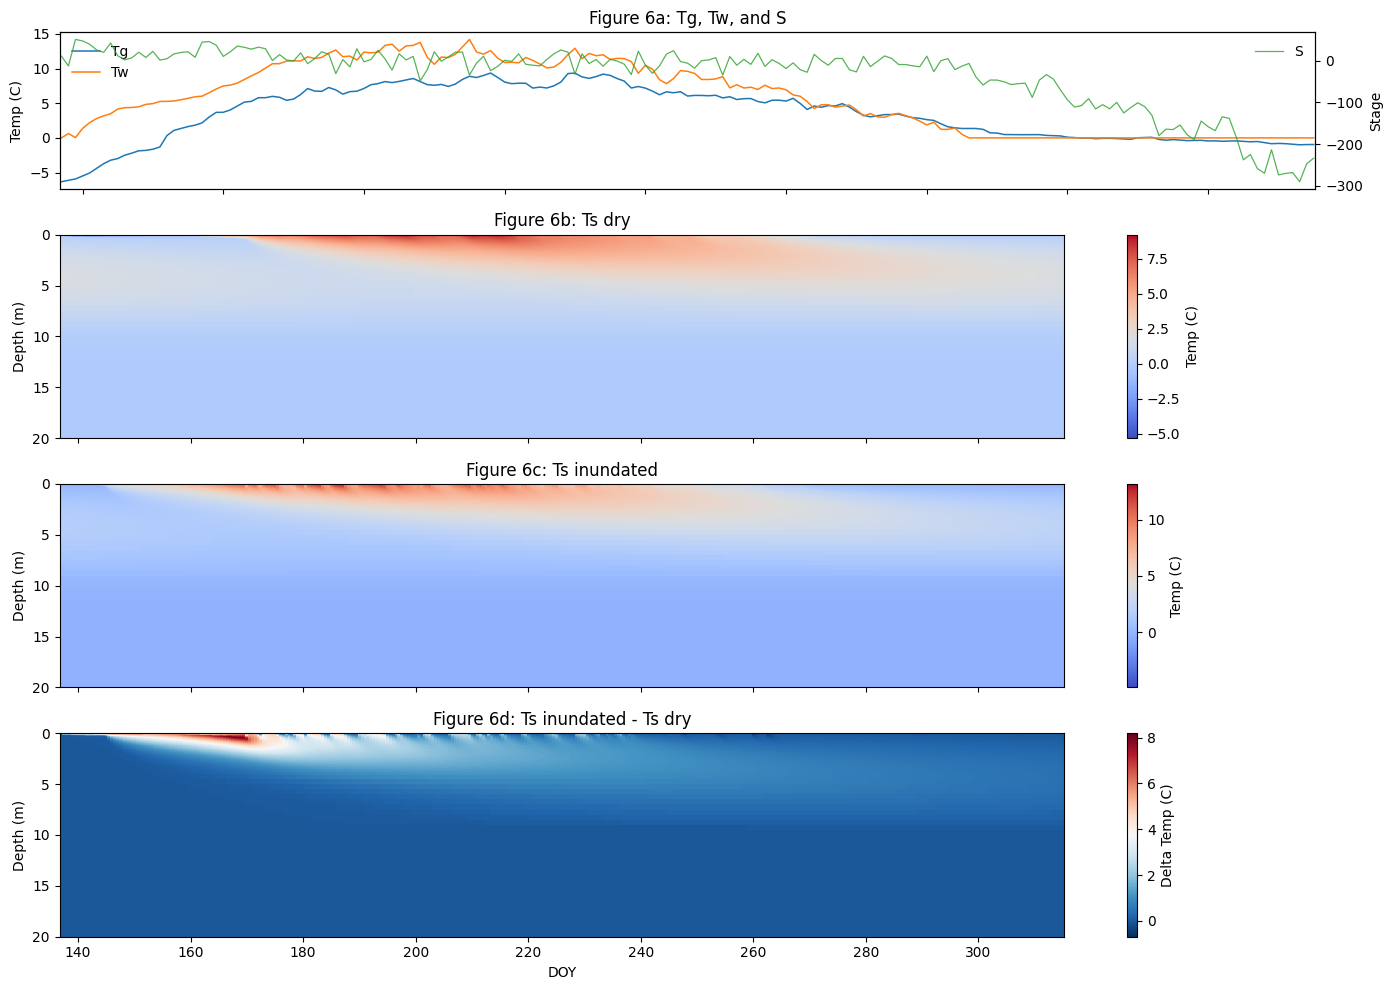

In [17]:
ds = run_fig6_case(
    forcing_df,
    spinup_years=100,
    dt=0.5,
    spinup_cache_path=spinup_cache_path,
    model_kwargs={
        'total_depth': 20.0,
        'fine_depth': 4.0,
        'dz_fine': 0.05,
        'dz_coarse': 0.5,
        'stage_threshold': stage_threshold,
    },
)
fig, axes = plot_fig6_dataset(ds)
ds


In [11]:
ds[['active_layer_depth_dry', 'active_layer_depth_inundated']].to_dataframe().head()


,active_layer_depth_dry,active_layer_depth_inundated
time,,
137.0,0.0,0.0
137.5,0.0,0.0
138.0,0.0,0.0
138.5,0.0,0.0
139.0,0.0,0.0
